# EDA on Order Dataset


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df=pd.read_excel('CleanOrdersData.xlsx')

# statistics values of the data
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month,Day,WeekNum
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,2023.767500,5.995000,15.969167,24.413333
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,2023.000000,1.000000,1.000000,1.000000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,2023.000000,3.000000,8.000000,12.000000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,2024.000000,6.000000,16.000000,23.000000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,2024.000000,9.000000,24.000000,36.000000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,2025.000000,12.000000,31.000000,52.000000
std,NaN,1.407557,197.177146,2.281983,819.856558,0.750942,3.344293,8.762450,14.604002


In [62]:
# Key Observations so far:

#  Average order is 3 items at $356 each
#  Average revenue per order is $1,054
#  Customers browse 5-6 items but purchase only 3
#  Data spans 2.5 years (2023-2025)

In [59]:
# IQR Method
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)]
print("IQR Outliers:", len(outliers_iqr))
print(f"Lower Bound : {lower}")
print(f"Upper Bound : {upper}")
print(outliers_iqr[['OrderID','Product','Quantity','UnitPrice','TotalPrice']])

IQR Outliers: 8
Lower Bound : -1341.4125
Upper Bound : 3330.4075
        OrderID  Product  Quantity  UnitPrice  TotalPrice
107   ORD200107  Printer         5     670.75     3353.75
326   ORD200326   Laptop         5     670.48     3352.40
328   ORD200328   Tablet         5     674.04     3370.20
469   ORD200469    Chair         5     676.98     3384.90
632   ORD200632   Laptop         5     678.16     3390.80
789   ORD200789   Tablet         5     691.28     3456.40
1065  ORD201065  Printer         5     666.80     3334.00
1122  ORD201122  Monitor         5     678.19     3390.95


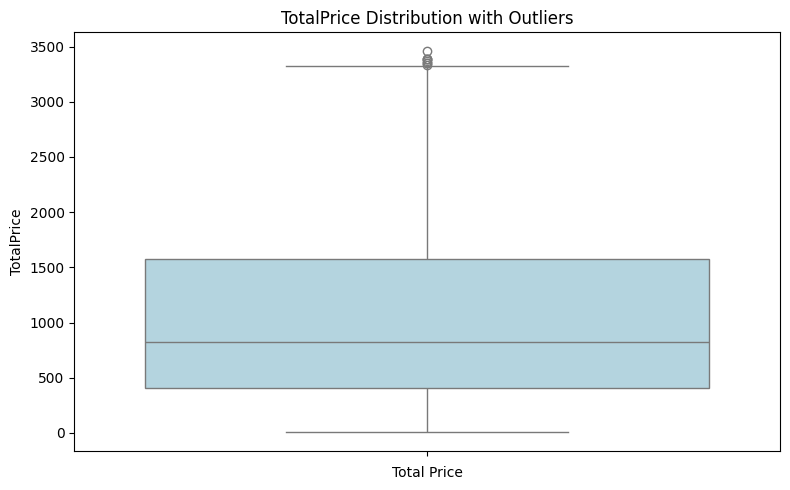

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['TotalPrice'], color='lightblue')
plt.title('TotalPrice Distribution with Outliers')
plt.xlabel('Total Price')
plt.tight_layout()
plt.show()

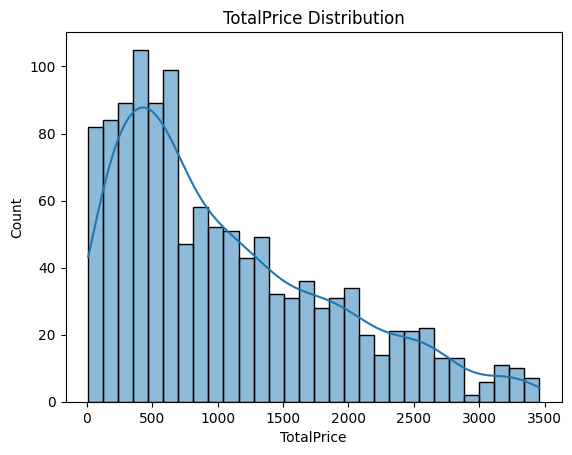

In [69]:
# Histogram
sns.histplot(df['TotalPrice'], bins=30, kde=True)
plt.title('TotalPrice Distribution')
plt.show()

In [70]:
lower = df['TotalPrice'].quantile(0.01)
upper = df['TotalPrice'].quantile(0.99)
outliers_p = df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)]
print(f"Lower Bound : {lower}")
print(f"Upper Bound : {upper}")
print(f"Percentile Outliers: {len(outliers_p)}")

Lower Bound : 36.5889
Upper Bound : 3277.911
Percentile Outliers: 24


In [71]:
low_orders = df[df['TotalPrice'] < 36.58]
print(low_orders[['OrderID','Product','Quantity','UnitPrice','TotalPrice']])

        OrderID  Product  Quantity  UnitPrice  TotalPrice
49    ORD200049  Printer         1      30.44       30.44
240   ORD200240   Tablet         1      17.24       17.24
303   ORD200303   Tablet         1      30.54       30.54
336   ORD200336   Laptop         1      18.20       18.20
473   ORD200473    Chair         2      14.93       29.86
542   ORD200542   Tablet         1      17.98       17.98
690   ORD200690  Monitor         1      24.48       24.48
776   ORD200776   Tablet         1      21.19       21.19
863   ORD200863    Phone         1      14.06       14.06
926   ORD200926     Desk         1      26.95       26.95
1025  ORD201025    Chair         1      23.53       23.53
1161  ORD201161    Phone         1      11.39       11.39


In [57]:
# Z-Score Method
from scipy import stats
z_scores = stats.zscore(df['TotalPrice'])
outliers_z = df[abs(z_scores) > 3]
print("Z-Score Outliers:", len(outliers_z))

Z-Score Outliers: 0


In [72]:
# - IQR found 8 outliers mathematically
# - Z-Score found 0 outliers
# - Boxplot confirms outliers are clustered
# - All outliers are VALID orders
# - No action needed — dataset is clean!

In [ ]:
# year and Monthly sales trend
yearly_sales = df.groupby(['Year'])['TotalPrice'].sum().reset_index()
print(yearly_sales)

print("-"*50)

monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
print(monthly_sales)

   Year  TotalPrice
0  2023   552643.24
1  2024   480235.87
2  2025   231882.85
--------------------------------------------------
    Year  Month  TotalPrice
0   2023      1    56685.75
1   2023      2    40117.66
2   2023      3    48609.37
3   2023      4    27751.71
4   2023      5    63836.84
5   2023      6    49500.19
6   2023      7    42820.66
7   2023      8    54352.14
8   2023      9    29526.67
9   2023     10    52607.85
10  2023     11    43079.67
11  2023     12    43754.73
12  2024      1    38528.08
13  2024      2    36909.57
14  2024      3    36030.90
15  2024      4    49613.14
16  2024      5    27909.11
17  2024      6    68068.54
18  2024      7    42963.98
19  2024      8    31991.07
20  2024      9    39794.98
21  2024     10    37226.97
22  2024     11    32413.76
23  2024     12    38785.77
24  2025      1    29099.40
25  2025      2    35317.55
26  2025      3    39200.66
27  2025      4    31821.20
28  2025      5    43396.64
29  2025      6    53047.40


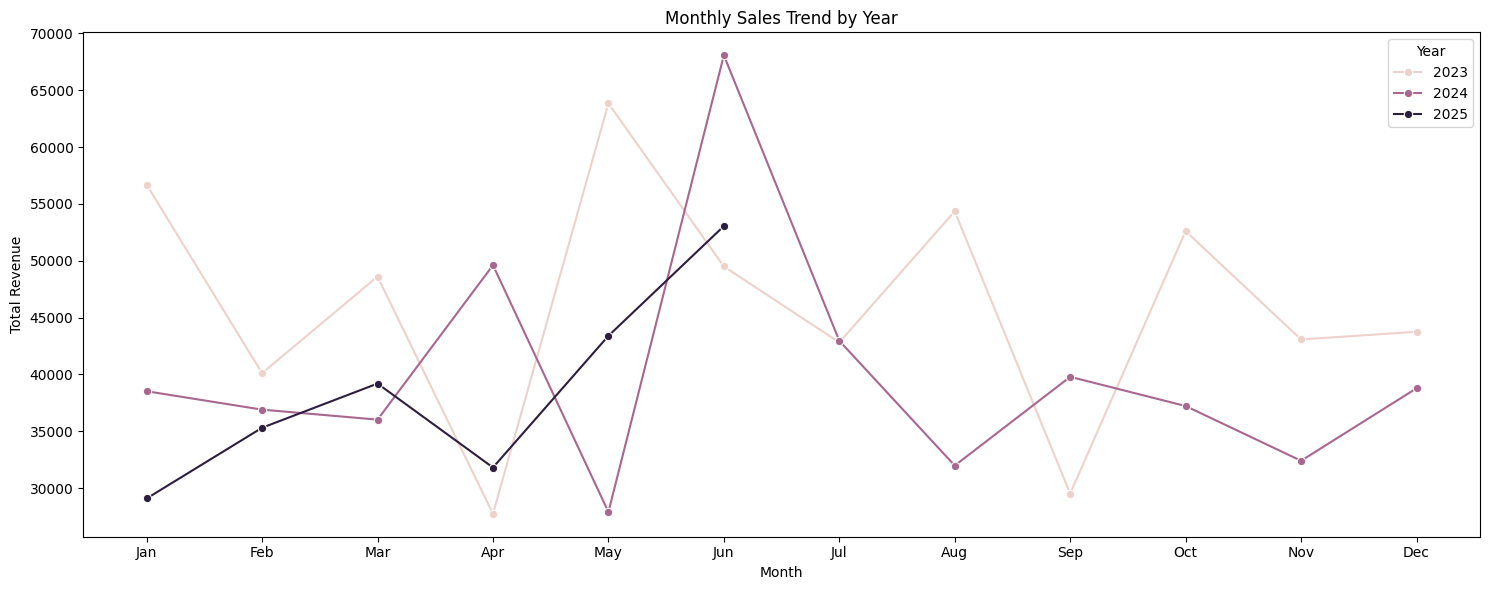

In [16]:
plt.figure(figsize=(15,6))
sns.lineplot(data=monthly_sales, x='Month', y='TotalPrice', hue='Year', marker='o')
plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

In [ ]:
# Key Observations:

#  2024 revenue dropped compared to 2023
#  June is consistently strong across years
#  April & May show weakness in some years
#  Sales are fluctuating — no clear consistent growth trend
#  2025 is on track — June 2025 already strong at $53,047


In [22]:
# Revenue by Product
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=True).reset_index()
print(product_sales)

   Product  TotalPrice
0    Phone   151722.39
1     Desk   167459.93
2  Monitor   175651.41
3   Tablet   186568.95
4   Laptop   192126.56
5  Printer   195612.61
6    Chair   195620.11


C:\Users\dd\AppData\Local\Temp\ipykernel_17780\459221777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_sales, x='Product', y='TotalPrice', palette='viridis' )


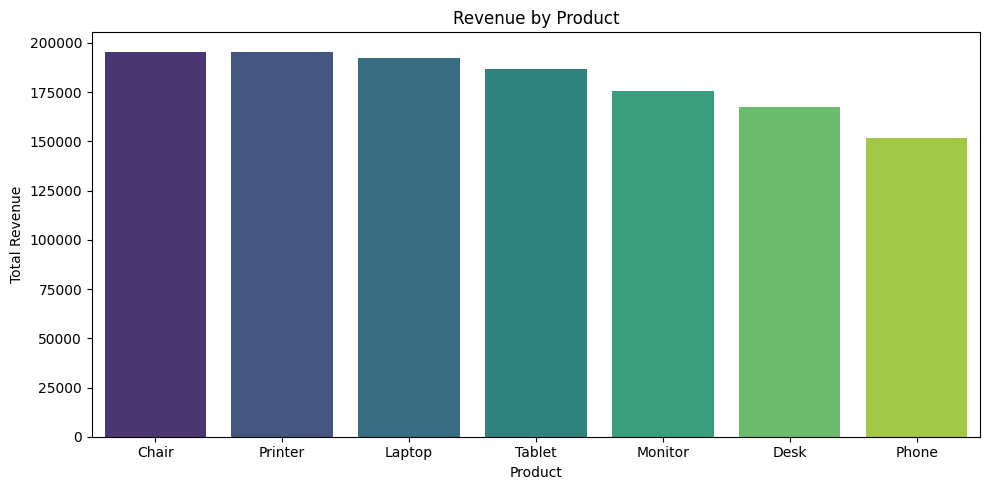

In [30]:
plt.figure(figsize=(10,5))
sorted_sales = product_sales.sort_values("TotalPrice", ascending=False)
sns.barplot(data=sorted_sales, x='Product', y='TotalPrice', palette='viridis' )
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

In [ ]:
# Key Observations:

#  Chair is the top revenue product — $195,620
#  Printer is extremely close — only $7.50 difference!
#  Phone is the lowest revenue product — $151,722
#  Top 4 products (Chair, Printer, Laptop, Tablet) are very close in revenue
#  Revenue is evenly distributed across products — no single dominant product

In [40]:
# Revenue by Payment Method
payment_sales = df.groupby('PaymentMethod')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# Order count by Payment Method
payment_count = df.groupby('PaymentMethod')['OrderID'].count().sort_values(ascending=False).reset_index()
payment_count.columns = ['PaymentMethod', 'OrderCount'] 

print(payment_sales)
print(payment_count)

  PaymentMethod  TotalPrice
0   Credit Card   263847.63
1        Online   262442.94
2          Cash   259786.29
3     Gift Card   246323.92
4    Debit Card   232361.18
  PaymentMethod  OrderCount
0        Online         258
1          Cash         246
2   Credit Card         234
3    Debit Card         232
4     Gift Card         230


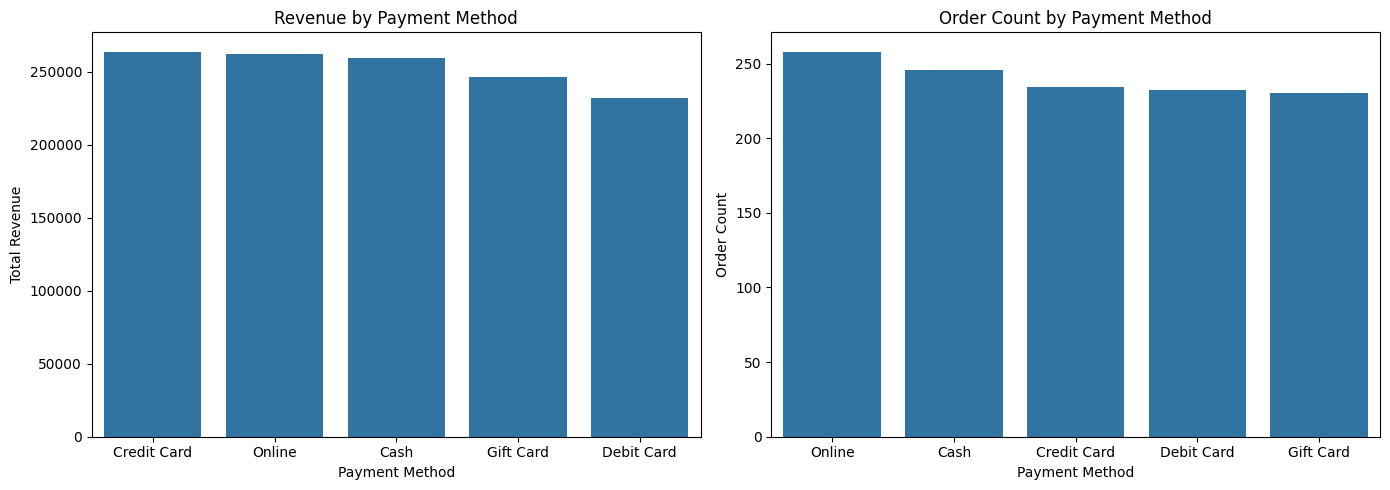

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=payment_sales, x='PaymentMethod', y='TotalPrice', ax=ax1)
ax1.set_title('Revenue by Payment Method')
ax1.set_xlabel('Payment Method')
ax1.set_ylabel('Total Revenue')

sns.barplot(data=payment_count, x='PaymentMethod', y='OrderCount', ax=ax2)
ax2.set_title('Order Count by Payment Method')
ax2.set_xlabel('Payment Method')
ax2.set_ylabel('Order Count')

plt.tight_layout()
plt.show()

In [45]:
# Key Observations:
#  Credit Card leads in Revenue

# Highest revenue — $263,847
# But only 234 orders → higher avg order value

#  Online leads in Order Count

# Most orders — 258
# But 2nd in revenue → lower avg order value per order

#  Cash is surprisingly strong

# 3rd in revenue, 1st in order count (246)
# Shows many customers still prefer cash

#  Gift Card & Debit Card are lowest

# Both below $250K revenue
# Least preferred payment methods


In [46]:
# Order Status Analysis
status_count = df.groupby('OrderStatus')['OrderID'].count().reset_index()
status_count.columns = ['OrderStatus', 'OrderCount']
status_revenue = df.groupby('OrderStatus')['TotalPrice'].sum().reset_index()

print(status_count)
print(status_revenue)

  OrderStatus  OrderCount
0   Cancelled         250
1   Delivered         231
2     Pending         237
3    Returned         247
4     Shipped         235
  OrderStatus  TotalPrice
0   Cancelled   276396.21
1   Delivered   242600.32
2     Pending   256328.15
3    Returned   243277.70
4     Shipped   246159.58


C:\Users\dd\AppData\Local\Temp\ipykernel_17780\3087923304.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_count, x='OrderStatus', y='OrderCount', palette='RdYlGn', ax=ax1)
C:\Users\dd\AppData\Local\Temp\ipykernel_17780\3087923304.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_revenue, x='OrderStatus', y='TotalPrice', palette='RdYlGn', ax=ax2)


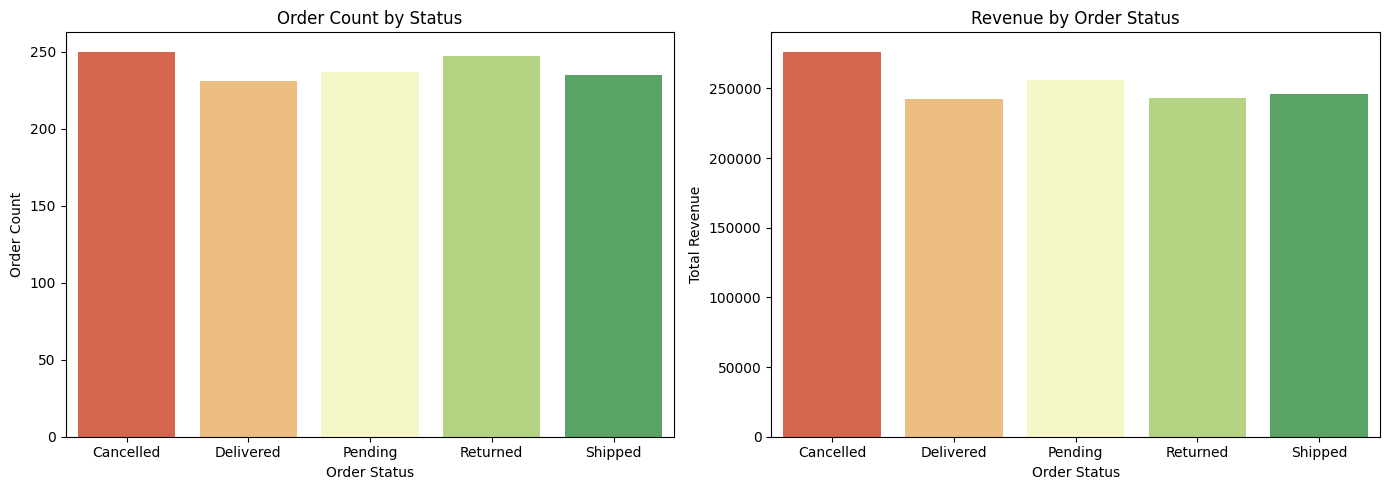

In [48]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=status_count, x='OrderStatus', y='OrderCount', palette='RdYlGn', ax=ax1)
ax1.set_title('Order Count by Status')
ax1.set_xlabel('Order Status')
ax1.set_ylabel('Order Count')

sns.barplot(data=status_revenue, x='OrderStatus', y='TotalPrice', palette='RdYlGn', ax=ax2)
ax2.set_title('Revenue by Order Status')
ax2.set_xlabel('Order Status')
ax2.set_ylabel('Total Revenue')

plt.tight_layout()
plt.show()

In [49]:
# Key Observations: 

# Order Count:

# Cancelled bar is clearly the tallest — most frequent status
# Returned is 2nd tallest — serious issue
# Delivered is the lowest — concerning!
# All bars between 230-250 — very narrow range

#  Revenue:

# Cancelled revenue bar stands out — highest revenue lost
# All other statuses are almost equal height
# Visual clearly shows cancellation is the biggest problem

In [50]:
# Referral Source Analysis
referral_count = df.groupby('ReferralSource')['OrderID'].count().reset_index()
referral_count.columns = ['ReferralSource', 'OrderCount']
referral_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().reset_index()

print(referral_count)
print(referral_revenue)

  ReferralSource  OrderCount
0          Email         250
1       Facebook         228
2         Google         241
3      Instagram         259
4       Referral         222
  ReferralSource  TotalPrice
0          Email   261808.55
1       Facebook   250410.90
2         Google   250441.48
3      Instagram   275285.45
4       Referral   226815.58


C:\Users\dd\AppData\Local\Temp\ipykernel_17780\863016770.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=referral_count, x='ReferralSource', y='OrderCount', palette='Set2', ax=ax1)
C:\Users\dd\AppData\Local\Temp\ipykernel_17780\863016770.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=referral_revenue, x='ReferralSource', y='TotalPrice', palette='Set2', ax=ax2)


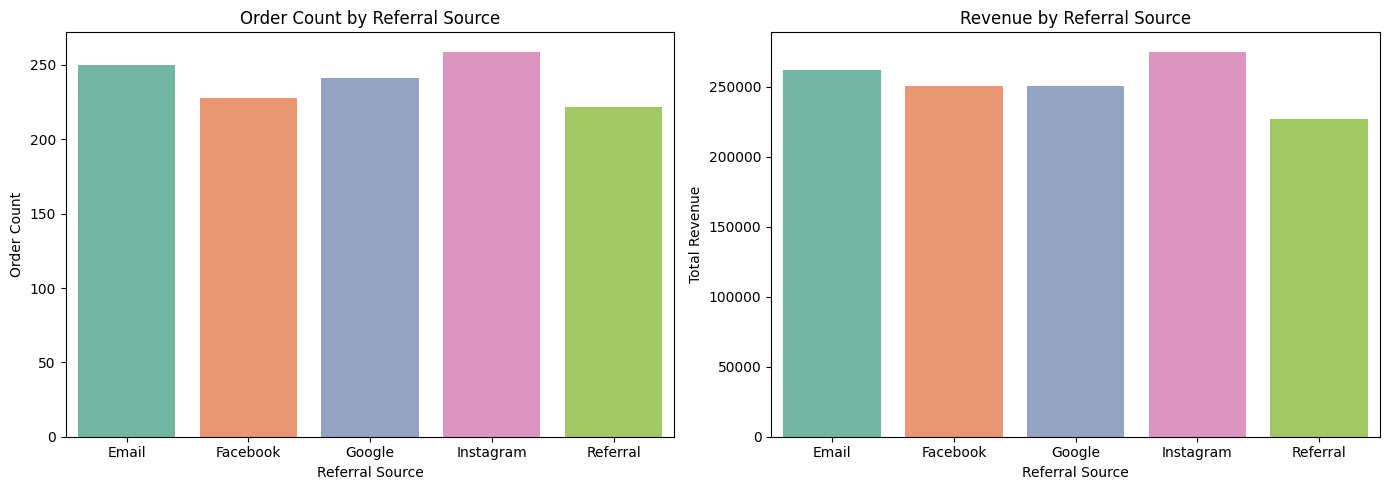

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=referral_count, x='ReferralSource', y='OrderCount', palette='Set2', ax=ax1)
ax1.set_title('Order Count by Referral Source')
ax1.set_xlabel('Referral Source')
ax1.set_ylabel('Order Count')

sns.barplot(data=referral_revenue, x='ReferralSource', y='TotalPrice', palette='Set2', ax=ax2)
ax2.set_title('Revenue by Referral Source')
ax2.set_xlabel('Referral Source')
ax2.set_ylabel('Total Revenue')

plt.tight_layout()
plt.show()

In [52]:
# # Order Count:

#  Instagram bar is clearly tallest — most orders
#  Email is 2nd — strong performance
#  Referral is shortest — least orders
#  Overall bars are close in height (222-259 range)

#  Revenue:

#  Instagram pink bar stands out — highest revenue
#  Email is 2nd — consistent with order count
#  Referral is lowest — weakest channel
# Google & Facebook almost identical — hard to tell apart

In [53]:
# Coupon Code Analysis
coupon_count = df.groupby('CouponCode')['OrderID'].count().reset_index()
coupon_count.columns = ['CouponCode', 'OrderCount']
coupon_revenue = df.groupby('CouponCode')['TotalPrice'].sum().reset_index()

print(coupon_count)
print(coupon_revenue)

  CouponCode  OrderCount
0   FREESHIP         313
1  NO Coupan         309
2     SAVE10         286
3   WINTER15         292
  CouponCode  TotalPrice
0   FREESHIP   335036.99
1  NO Coupan   322401.41
2     SAVE10   304840.02
3   WINTER15   302483.54


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=coupon_count, x='CouponCode', y='OrderCount', palette='pastel', ax=ax1)
ax1.set_title('Order Count by Coupon Code')
ax1.set_xlabel('Coupon Code')
ax1.set_ylabel('Order Count')

sns.barplot(data=coupon_revenue, x='CouponCode', y='TotalPrice', palette='pastel', ax=ax2)
ax2.set_title('Revenue by Coupon Code')
ax2.set_xlabel('Coupon Code')
ax2.set_ylabel('Total Revenue')

plt.tight_layout()
plt.show()

In [ ]:
# Order Count:

#  FREESHIP is clearly tallest — most orders
#  No Coupon is 2nd — strong without discount
#  SAVE10 is shortest — least orders
# Bars range from 286-313 — relatively close

#  Revenue:

#  FREESHIP leads revenue — highest bar
#  SAVE10 & WINTER15 almost equal — very similar height
# Overall revenue range $302K — $335K — balanced

In [8]:
print("=" * 60)
print("       EXPLORATORY DATA ANALYSIS - ORDERS DATASET Full Summary:")
print("=" * 60)

print("\n BASIC STATISTICS")
print("-" * 60)
print(f"Total Orders        : 1,200")
print(f"Total Revenue       : $1,264,761.96")
print(f"Average Order Value : $1,053.97")
print(f"Date Range          : Jan 2023 — Jun 2025")

print("\n MONTHLY TRENDS")
print("-" * 60)
print("• Best Month        : June 2024 ($68,068)")
print("• Worst Month       : April 2023 ($27,751)")
print("• Best Year         : 2023 ($552,643)")
print("• 2025 Trend        : Upward ↑")

print("\n PRODUCT ANALYSIS")
print("-" * 60)
print("• Top Product       : Chair ($195,620)")
print("• Lowest Product    : Phone ($151,722)")
print("• Insight           : Balanced portfolio")

print("\n PAYMENT METHOD")
print("-" * 60)
print("• Highest Revenue   : Credit Card ($263,847)")
print("• Most Orders       : Online (258 orders)")
print("• Insight           : All methods equally preferred")

print("\n ORDER STATUS")
print("-" * 60)
print("• Cancellation Rate : 20.8% (250 orders)")
print("• Return Rate       : 20.6% (247 orders)")
print("• Combined Loss     : 41.4% ")
print("• Revenue at Risk   : $519,673")

print("\n REFERRAL SOURCE")
print("-" * 60)
print("• Top Channel       : Instagram (259 orders)")
print("• 2nd Channel       : Email (250 orders)")
print("• Weakest Channel   : Referral (222 orders)")

print("\n COUPON CODE")
print("-" * 60)
print("• Best Coupon       : FREESHIP (313 orders)")
print("• No Coupon Orders  : 309 orders")
print("• Insight           : Free shipping beats % discounts")

print("\n" + "=" * 60)
print("          TOP 3 CRITICAL FINDINGS")
print("=" * 60)
print("1. 41.4% orders cancelled/returned — needs attention!")
print("2. Instagram is #1 growth channel — invest more!")
print("3. June is peak month — plan campaigns accordingly!")
print("=" * 60)
print("            EDA COMPLETED SUCCESSFULLY")
print("=" * 60)

       EXPLORATORY DATA ANALYSIS - ORDERS DATASET Full Summary:

 BASIC STATISTICS
------------------------------------------------------------
Total Orders        : 1,200
Total Revenue       : $1,264,761.96
Average Order Value : $1,053.97
Date Range          : Jan 2023 — Jun 2025

 MONTHLY TRENDS
------------------------------------------------------------
• Best Month        : June 2024 ($68,068)
• Worst Month       : April 2023 ($27,751)
• Best Year         : 2023 ($552,643)
• 2025 Trend        : Upward ↑

 PRODUCT ANALYSIS
------------------------------------------------------------
• Top Product       : Chair ($195,620)
• Lowest Product    : Phone ($151,722)
• Insight           : Balanced portfolio

 PAYMENT METHOD
------------------------------------------------------------
• Highest Revenue   : Credit Card ($263,847)
• Most Orders       : Online (258 orders)
• Insight           : All methods equally preferred

 ORDER STATUS
-------------------------------------------------------